# 1D CNN template (PyTorch)

## Conv1d output length

For each layer, sequence length evolves as:

\[
L_{\text{out}} = \left\lfloor \frac{L_{\text{in}} + 2p - d\,(k-1) - 1}{s} + 1 \right\rfloor
\]

Where:

- \(L_{\text{in}}\): samples along time (your sequence length)
- \(k\): **kernel_size**
- \(s\): **stride**
- \(p\): **padding**
- \(d\): **dilation** (default `1`)

Apply this **from left to right** through each `Conv1d`; then do the same for `MaxPool1d` / `AvgPool1d` (same formula).

**Channels:** `Conv1d` maps `in_channels` → `out_channels`. Depth (channel count) does **not** change \(L_{\text{out}}\); only time length does.

**BatchNorm1d:** use `BatchNorm1d(num_features=out_channels)` right after conv (expects shape `[batch, channels, length]`).

---

## Avoiding manual “flatten size” math

Two common patterns:

1. **`nn.AdaptiveAvgPool1d(1)`** at the end of the conv stack → output `[B, C, 1]`, then `flatten` → `[B, C]`. Classifier is `Linear(C, num_classes)`. Adding layers changes `C`; you still only update one `Linear` input dim.

2. **Compute explicitly** once: run `model.features(torch.zeros(1, 1, T))` (dummy batch) and `numel()`, or print `.shape`.

---

## Checklist when you add layers

- Match **`in_channels`** of the next conv to the **previous conv’s `out_channels`** (or pooling doesn’t touch channels).
- After changing kernels/strides/pools, sanity-check **`L`** with the formula above (or dummy forward).
- If training is unstable with deeper nets, smaller learning rate / more normalization / residual blocks (later step).

In [6]:
import torch
import torch.nn as nn


class CNN1D_v1(nn.Module):

    def __init__(self, num_classes: int = 3):
        super().__init__()
        # Stack: Conv → BN → ReLU → Pool (repeat / deepen as needed)
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=4, stride=4),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=4, stride=4),
            # Global pooling: output [B, 64, 1] regardless of length (within reason)
            nn.AdaptiveAvgPool1d(output_size=1),
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: [B, 1, T]
        h = self.features(x)
        h = h.squeeze(-1)
        return self.classifier(h)


# Sanity check shapes (adjust T to match your crop length)
if __name__ == "__main__":
    batch, channels, T = 4, 1, 37_000  # e.g. 5 s × 7400 Hz
    model = CNN1D_v1(num_classes=3)
    dummy = torch.randn(batch, channels, T)
    logits = model(dummy)
    print("Input:", dummy.shape)
    print("Output (logits):", logits.shape)  # [B, num_classes]


Input: torch.Size([4, 1, 37000])
Output (logits): torch.Size([4, 3])


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import random
import os
import time

def test_accuracy(model, loss_fn, val_loader, device):
    correct = 0
    total = 0
    total_loss = 0.0

    model.eval()
    with torch.no_grad():
        for x, labels in val_loader:
            x, labels = x.to(device), labels.to(device)
            outputs = model(x)

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Calculate loss
            loss = loss_fn(outputs, labels)
            total_loss += loss.item() * x.size(0)

    if total == 0:
        raise RuntimeError("val_loader produced no samples")

    accuracy = 100.0 * correct / total
    avg_loss = total_loss / total

    model.train()
    return accuracy, avg_loss

# Train Function
def train(model, loss_fn, optimizer, train_loader, val_loader, num_epochs, device):

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    epoch_durations = []

    model.train()
    # Iterate through all Epochs
    for epoch in range(num_epochs):
        total_loss = 0
        total = 0
        correct = 0
        start_time = time.time() # Record epoch start time

        # Iterate through training dataset
        for x, labels in train_loader:
            # Load x / labels
            x, labels = x.to(device), labels.to(device)
            # Zero collected gradients at each step
            optimizer.zero_grad()
            # Forward Propagate
            outputs = model(x)
            # Calculate Loss
            loss = loss_fn(outputs, labels)
            # Back propagate
            loss.backward()
            # Update weights
            optimizer.step()

            # track loss during current epoch
            total_loss += loss.item() * x.size(0)

            # track correct predictions during current epoch
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # store loss and accuracy for current epoch
        train_losses.append(total_loss / len(train_loader.dataset))
        train_accuracies.append(100 * correct / total)

        # run model on val data and store val loss and accuracy
        val_accuracy, val_loss = test_accuracy(model, loss_fn, val_loader, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # Print statistics after every epoch
        print('Epoch [%d/%d], Training Loss: %.4f, Training Accuracy: %.4f, Validation Loss: %.4f, Validation Accuracy: %.4f'
                %(epoch+1, num_epochs,
                train_losses[-1], train_accuracies[-1],
                val_losses[-1], val_accuracies[-1]))

        end_time = time.time()
        epoch_duration = end_time - start_time
        print(f'Epoch {epoch+1} finished in {epoch_duration:.2f} seconds')
        epoch_durations.append(epoch_duration)

    return train_losses, train_accuracies, val_losses, val_accuracies, epoch_durations
    
def plot_learning_curves(train_losses, val_losses, train_accs, val_accs):
    train_losses = [t.cpu().numpy() if isinstance(t, torch.Tensor) else t for t in train_losses]
    val_losses = [t.cpu().numpy() if isinstance(t, torch.Tensor) else t for t in val_losses]
    train_accs = [t.cpu().numpy() if isinstance(t, torch.Tensor) else t for t in train_accs]
    val_accs = [t.cpu().numpy() if isinstance(t, torch.Tensor) else t for t in val_accs]
    
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.title("Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label="Train Acc")
    plt.plot(epochs, val_accs, label="Val Acc")
    plt.title("Accuracy Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [8]:
from pathlib import Path

from torch.utils.data import DataLoader

from vibration_data import make_train_val_datasets

# Jupyter: cwd should be the repo root (`174-SeniorDesign-VibrationDetection`) when you open the folder.
PROJECT_ROOT = Path.cwd()
INDEX_CSV = PROJECT_ROOT / "dataset" / "index.csv"
sample_rate = 7400

if not INDEX_CSV.is_file():
    raise FileNotFoundError(
        f"Missing {INDEX_CSV}. Export the dataset from clip_separation.ipynb first, "
        "or set the notebook working directory to the repo root."
    )

train_ds, val_ds = make_train_val_datasets(
    str(INDEX_CSV),
    train_ratio=0.8,
    seed=42,
    sample_rate=sample_rate,
    window_seconds=5.0,
    normalize="zscore",
)

batch_size = 8
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))


Train batches: 4 | Val batches: 10


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else
                      "xpu" if torch.xpu.is_available() else
                      "cpu")

print(f"Using device: {device}")

# comment out the two lines below to continue training instead of restarting training
model = CNN1D_v1(num_classes=3)
model.to(device)

num_epochs = 25
lr = 1e-5

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_losses, train_accs, val_losses, val_accs, epoch_durations = train(model, loss_function, optimizer, train_loader, val_loader, num_epochs, device)

Using device: xpu
Epoch [1/25], Training Loss: 1.1380, Training Accuracy: 41.3793, Validation Loss: 1.0944, Validation Accuracy: 36.3636
Epoch 1 finished in 0.23 seconds
Epoch [2/25], Training Loss: 1.1292, Training Accuracy: 34.4828, Validation Loss: 1.0939, Validation Accuracy: 36.3636
Epoch 2 finished in 0.20 seconds
Epoch [3/25], Training Loss: 1.1402, Training Accuracy: 44.8276, Validation Loss: 1.0930, Validation Accuracy: 40.2597
Epoch 3 finished in 0.21 seconds
Epoch [4/25], Training Loss: 1.1260, Training Accuracy: 37.9310, Validation Loss: 1.0916, Validation Accuracy: 46.7532
Epoch 4 finished in 0.21 seconds
Epoch [5/25], Training Loss: 1.1259, Training Accuracy: 41.3793, Validation Loss: 1.0904, Validation Accuracy: 48.0519
Epoch 5 finished in 0.19 seconds
Epoch [6/25], Training Loss: 1.1310, Training Accuracy: 48.2759, Validation Loss: 1.0898, Validation Accuracy: 49.3506
Epoch 6 finished in 0.21 seconds
Epoch [7/25], Training Loss: 1.1244, Training Accuracy: 41.3793, Valid

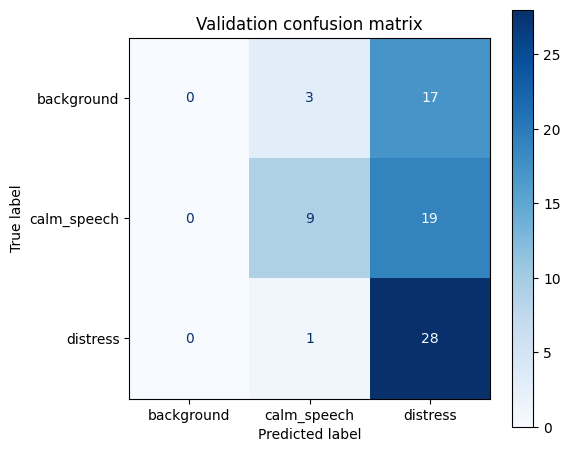

CNN1D_v1(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (8): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Linear(in_features=64, out_features=3, bias=True)
)

In [12]:
# Validation confusion matrix — run after training so `model`, `val_loader`, and `device` are defined.
label_names = ["background", "calm_speech", "distress"]

model.eval()
all_true, all_pred = [], []
with torch.no_grad():
    for x, labels in val_loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1)
        all_true.append(labels.cpu().numpy())
        all_pred.append(preds.cpu().numpy())

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred, labels=np.arange(len(label_names))),
    display_labels=label_names,
)
disp.plot(ax=ax, values_format="d", cmap="Blues")
ax.set_title("Validation confusion matrix")
plt.tight_layout()
plt.show()

# restore training mode if you continue tuning
model.train()

## Bandpass-filtered inputs

Waveforms from the CSV pipeline are cropped (train: random window, val: fixed segments). For this section:

1. **Bandpass** the raw cropped window (**before** z-score) using SciPy `sosfiltfilt`.
2. **Z-score** and batch as usual.

Adjust **`bp_low_hz`**, **`bp_high_hz`**, and **`bp_order`** in the next cell. Nyquist here is **`sample_rate / 2`**; keep the passband strictly inside `(0, Nyquist)`. Re-run that cell anytime you change frequencies, then reloaders and train again.

Re-run the **confusion matrix** cell above if you want the matrix under the filtered loaders.

In [13]:
import importlib

import vibration_data as _vibration_data
importlib.reload(_vibration_data)
from vibration_data import make_train_val_datasets

from scipy.signal import butter, sosfiltfilt


def bandpass_numpy(x, sample_rate_hz, low_hz, high_hz, order=4):
    """Bandpass filtering on numpy 1D (applied before z-score in the dataset)."""
    sos = butter(order, [low_hz, high_hz], btype="band", fs=sample_rate_hz, output="sos")
    x64 = np.asarray(x, dtype=np.float64)
    y = sosfiltfilt(sos, x64)
    return y.astype(np.float32)


# --- Adjustable passband (Hz) ---
bp_low_hz = 200.0
bp_high_hz = 1000.0
bp_order = 4

nyquist = sample_rate / 2.0
if not (0 < bp_low_hz < bp_high_hz < nyquist):
    raise ValueError(f"Require 0 < low < high < Nyquist ({nyquist:.1f} Hz); got [{bp_low_hz}, {bp_high_hz}]")


def _bandpass_before_norm(x_np):
    return bandpass_numpy(x_np, sample_rate, bp_low_hz, bp_high_hz, order=bp_order)


train_ds, val_ds = make_train_val_datasets(
    str(INDEX_CSV),
    train_ratio=0.8,
    seed=42,
    sample_rate=sample_rate,
    window_seconds=5.0,
    normalize="zscore",
    transform_before_normalize=_bandpass_before_norm,
)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

print(
    f"Loaders rebuilt: bandpass {bp_low_hz:.1f}-{bp_high_hz:.1f} Hz, order={bp_order}"
)
print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))

TypeError: make_train_val_datasets() got an unexpected keyword argument 'transform_before_normalize'

In [ ]:
# Train on bandpass-filtered loaders (fresh model weights).
_device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "xpu"
    if getattr(torch, "xpu", None) is not None and torch.xpu.is_available()
    else "cpu"
)
print(f"Using device: {_device}")

model = CNN1D_v1(num_classes=3).to(_device)
device = _device

num_epochs = 25
lr = 1e-5

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_losses, train_accs, val_losses, val_accs, epoch_durations = train(
    model, loss_function, optimizer, train_loader, val_loader, num_epochs, device
)